## [作業重點]
確保你了解隨機森林模型中每個超參數的意義，並觀察調整超參數對結果的影響

## 作業

1. 試著調整 RandomForestClassifier(...) 中的參數，並觀察是否會改變結果？
2. 改用其他資料集 (boston, wine)，並與回歸模型與決策樹的結果進行比較

In [1]:
from sklearn import datasets, metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# 讀取鳶尾花資料集
iris = datasets.load_iris()

# 切分訓練集/測試集
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.25, random_state=4)

# 建立模型 (使用 20 顆樹，每棵樹的最大深度為 4)
clf = RandomForestClassifier(criterion='entropy',n_estimators=200, max_depth=3,random_state=0)
#(n_estimators=20, max_depth=4)

# 訓練模型
clf.fit(x_train, y_train)

# 預測測試集
y_pred = clf.predict(x_test)
acc = metrics.accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)
print(iris.feature_names)
print("Feature importance: ", clf.feature_importances_)

Accuracy:  0.9736842105263158
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Feature importance:  [0.09975442 0.02080546 0.4306639  0.44877623]


In [2]:
# 讀取鳶尾花資料集
wines = datasets.load_wine()

# 切分訓練集/測試集
x_train, x_test, y_train, y_test = train_test_split(wines.data, wines.target, test_size=0.25, random_state=4)

# 建立模型 (使用 20 顆樹，每棵樹的最大深度為 4)
clf = RandomForestClassifier(criterion='entropy',n_estimators=200, max_depth=3,random_state=0)
#(n_estimators=20, max_depth=4)

# 訓練模型
clf.fit(x_train, y_train)

# 預測測試集
y_pred = clf.predict(x_test)
acc = metrics.accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)
print(iris.feature_names)
print("Feature importance: ", clf.feature_importances_)

Accuracy:  0.9777777777777777
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Feature importance:  [0.09565452 0.02954251 0.00906299 0.02367616 0.03211476 0.06469601
 0.1758353  0.00938218 0.01908936 0.16320441 0.07385651 0.12778229
 0.176103  ]


## 延伸：混淆矩陣 (Confusion Matrix) 視覺化

針對 iris 與 wine 兩個資料集的 RandomForest 模型繪製混淆矩陣，使用彩色 (viridis) 配色，並在每個格子標註「數量」與「百分比」（以每個真實類別為基準），直觀檢視各類別的分類正確與誤判情形，最後將圖表存成 PNG 圖片檔。

Saved confusion_matrix_iris.png  (accuracy = 0.9737)


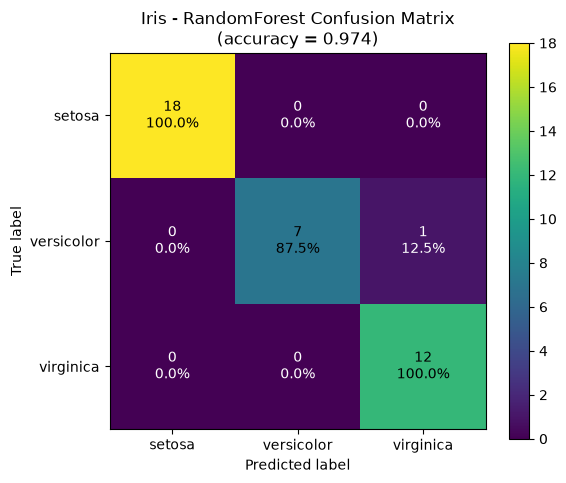

Saved confusion_matrix_wine.png  (accuracy = 0.9778)


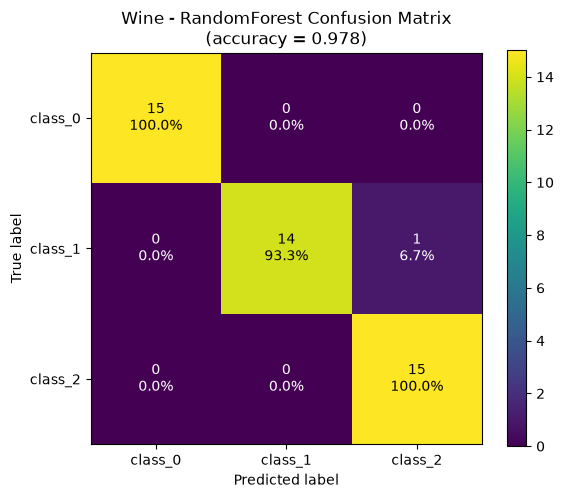

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def plot_and_save_confusion_matrix(dataset, title, filename):
    """訓練 RandomForest，繪製彩色混淆矩陣（含數量與百分比）並存成圖片。"""
    x_train, x_test, y_train, y_test = train_test_split(
        dataset.data, dataset.target, test_size=0.25, random_state=4)

    clf = RandomForestClassifier(
        criterion='entropy', n_estimators=200, max_depth=3, random_state=0)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    acc = metrics.accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    # 以每個真實類別（每一列）為基準計算百分比
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=dataset.target_names)

    fig, ax = plt.subplots(figsize=(6, 5))
    # 使用彩色的 colormap
    disp.plot(ax=ax, cmap='viridis', colorbar=True)

    # 在每格加上「數量 + 百分比」標註，並依背景明暗自動調整文字顏色
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = 'white' if cm_percent[i, j] < 50 else 'black'
            disp.text_[i, j].set_text(f'{cm[i, j]}\n{cm_percent[i, j]:.1f}%')
            disp.text_[i, j].set_color(text_color)

    ax.set_title(f'{title} - RandomForest Confusion Matrix\n(accuracy = {acc:.3f})')
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    print(f'Saved {filename}  (accuracy = {acc:.4f})')
    plt.show()
    return cm


cm_iris = plot_and_save_confusion_matrix(iris, 'Iris', 'confusion_matrix_iris.png')
cm_wine = plot_and_save_confusion_matrix(wines, 'Wine', 'confusion_matrix_wine.png')